# 🇪🇬 Egyptian Arabic Summarization Fine-Tuning

This notebook fine-tunes the **Qwen3-VL** LoRA model on Egyptian Arabic summarization data.

### 📁 Data & Path Config
*   **Data Path:** `My Drive/NLP - Audio Project/summarization/train-00000-of-00001.parquet`
*   **Output Path:** `My Drive/NLP - Audio Project/summarization/finetuned_model`
*   **Hardware:** Optimized for **T4 GPU**.

In [ ]:
!pip install -q evaluate qwen-vl-utils accelerate bitsandbytes
!pip install -q --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 51.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import pandas as pd
import time
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    Qwen3VLForConditionalGeneration, # Correct class for Qwen3-VL
    AutoProcessor,                   # Recommended for VL models
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, PeftModel
import evaluate

# Paths
DRIVE_BASE = "/content/drive/My Drive/NLP - Audio Project/summarization"
DATA_PATH = os.path.join(DRIVE_BASE, "train-00000-of-00001.parquet")
OUTPUT_DIR = os.path.join(DRIVE_BASE, "training_output")
FINAL_MODEL_DIR = os.path.join(DRIVE_BASE, "finetuned_model")

MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
LORA_ID = "MINERVA-TEAM/qwen3-vl-egyptian-summarizer-v2-lora"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import torch
import pandas as pd
import time
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, PeftModel
import evaluate

# Paths
DRIVE_BASE = "/content/drive/My Drive/NLP - Audio Project/summarization"
DATA_PATH = os.path.join(DRIVE_BASE, "train-00000-of-00001.parquet")
OUTPUT_DIR = os.path.join(DRIVE_BASE, "training_output")
FINAL_MODEL_DIR = os.path.join(DRIVE_BASE, "finetuned_model")

MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
LORA_ID = "MINERVA-TEAM/qwen3-vl-egyptian-summarizer-v2-lora"

# 3. Load and Prepare Data
df = pd.read_parquet(DATA_PATH)
dataset = Dataset.from_pandas(df)

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer = processor.tokenizer
tokenizer.pad_token = tokenizer.eos_token

def preprocess_function(examples):
    texts = []
    for t, s in zip(examples['text'], examples['summarized_text']):
        messages = [
            {"role": "user", "content": f"Summarize this Egyptian Arabic text: {t}"},
            {"role": "assistant", "content": s}
        ]
        # Use the processor to apply the template
        texts.append(processor.apply_chat_template(messages, tokenize=False))

    model_inputs = tokenizer(texts, max_length=512, truncation=True, padding="max_length")
    model_inputs["labels"] = model_inputs["input_ids"].copy()
    return model_inputs

tokenized_dataset = dataset.map(preprocess_function, batched=True, remove_columns=dataset.column_names)
tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.1)
print(f"Dataset Ready. Train size: {len(tokenized_dataset['train'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

Map:   0%|          | 0/3689 [00:00<?, ? examples/s]

Dataset Ready. Train size: 3320


In [ ]:
from peft import prepare_model_for_kbit_training

# 4. Load Model with 4-bit Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading Base Model...")
base_model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# Prepare model for 4-bit training
base_model = prepare_model_for_kbit_training(base_model)
# Enable gradient checkpointing
base_model.gradient_checkpointing_enable()

print("Loading LoRA Adapter weights...")
model = PeftModel.from_pretrained(base_model, LORA_ID, is_trainable=True)
print("Model & Adapter Loaded.")

Loading Base Model...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Loading LoRA Adapter weights...


adapter_config.json:   0%|          | 0.00/936 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/66.1M [00:00<?, ?B/s]

Model & Adapter Loaded.


In [ ]:
# 5. Fine-Tuning Setup
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=1,      # Reduced to 1 for T4 stability
    gradient_accumulation_steps=16,     # Increased to keep total batch size at 16
    learning_rate=2e-4,
    num_train_epochs=3,                 # Increased epochs for better fine-tuning
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=50,
    fp16=True,
    optim="paged_adamw_8bit",           # Use 8-bit optimizer to save VRAM
    max_grad_norm=0.3,                  # Good practice for stable training
    warmup_ratio=0.03,
    lr_scheduler_type="constant",
    push_to_hub=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

# Optional: Clear cache before starting
torch.cuda.empty_cache()

print("Starting Training...")
train_result = trainer.train()

# Visualize Loss
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
plt.plot(train_loss)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.savefig(os.path.join(DRIVE_BASE, "loss_curve.png"))
plt.show()

model.save_pretrained(FINAL_MODEL_DIR)
print(f"Saved to {FINAL_MODEL_DIR}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting Training...


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
50,1.413816,1.426281
100,1.385325,1.368778
150,1.311707,1.325006
200,1.317335,1.301814
250,1.139329,1.296023
300,1.135172,1.285842
350,1.124182,1.273416
400,1.130276,1.258622


Map:   0%|          | 0/3689 [00:00<?, ? examples/s]

Loading Base Model for resume...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

Loading LoRA Adapter weights for resume...


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Resuming training from checkpoint: /content/drive/My Drive/NLP - Audio Project/summarization/training_output/checkpoint-600


[transformers] Warning: The following arguments do not match the ones in the `trainer_state.json` within the checkpoint directory: 
	eval_steps: 100 (from args) != 50 (from trainer_state.json)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
624,0.808715,0.823978


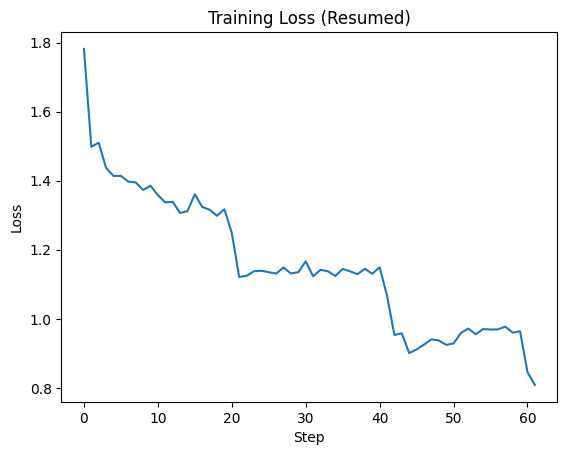

Saved resumed model to /content/drive/My Drive/NLP - Audio Project/summarization/finetuned_model


In [ ]:
# 6. Resume Training from Checkpoint

# --- Re-initialize dependencies for Trainer to make this cell self-contained ---
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    Qwen3VLForConditionalGeneration,
    AutoProcessor,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig
)
from peft import PeftModel, prepare_model_for_kbit_training

# Load and Prepare Data (replicating logic from earlier cells)
df = pd.read_parquet(DATA_PATH)
dataset = Dataset.from_pandas(df)

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer = processor.tokenizer
tokenizer.pad_token = tokenizer.eos_token

def preprocess_function(examples):
    texts = []
    for t, s in zip(examples['text'], examples['summarized_text']):
        messages = [
            {"role": "user", "content": f"Summarize this Egyptian Arabic text: {t}"},
            {"role": "assistant", "content": s}
        ]
        texts.append(processor.apply_chat_template(messages, tokenize=False))
    model_inputs = tokenizer(texts, max_length=512, truncation=True, padding="max_length")
    model_inputs["labels"] = model_inputs["input_ids"].copy()
    return model_inputs

tokenized_dataset = dataset.map(preprocess_function, batched=True, remove_columns=dataset.column_names)
tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.1)

# Load Model with 4-bit Quantization (replicating logic from earlier cells)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading Base Model for resume...")
base_model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

base_model = prepare_model_for_kbit_training(base_model)
base_model.gradient_checkpointing_enable()

print("Loading LoRA Adapter weights for resume...")
model = PeftModel.from_pretrained(base_model, LORA_ID, is_trainable=True)

# Fine-Tuning Setup (replicating logic from earlier cells)
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=2e-4,
    num_train_epochs=3,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=50, # Using the latest value from the notebook state
    fp16=True,
    optim="paged_adamw_8bit",
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    lr_scheduler_type="constant",
    push_to_hub=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)
# --- End Re-initialization ---


# Specify the checkpoint directory
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoint-600")

# Check if the checkpoint exists
if os.path.exists(CHECKPOINT_DIR):
    print(f"Resuming training from checkpoint: {CHECKPOINT_DIR}")
    # Resume training
    trainer.train(resume_from_checkpoint=CHECKPOINT_DIR)

    # Visualize Loss after resuming
    history = trainer.state.log_history
    train_loss = [x['loss'] for x in history if 'loss' in x]
    plt.plot(train_loss)
    plt.title("Training Loss (Resumed)")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.savefig(os.path.join(DRIVE_BASE, "loss_curve_resumed.png"))
    plt.show()

    # Save the final fine-tuned model after resuming
    model.save_pretrained(FINAL_MODEL_DIR)
    print(f"Saved resumed model to {FINAL_MODEL_DIR}")
else:
    print(f"Checkpoint {CHECKPOINT_DIR} not found. Please verify the path.")

In [9]:
!pip install -q rouge_score

  Preparing metadata (setup.py) ... done


In [1]:
!pip install -U bitsandbytes>=0.46.1

In [15]:
!pip install bert_score evaluate sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.4 MB/s eta 0:00:00


In [13]:
# Re-initialize necessary components if running this cell independently
import os
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from peft import PeftModel

from google.colab import drive
drive.mount('/content/drive')
# Paths and Model IDs (ensure these are defined, e.g., from earlier cells)
# DRIVE_BASE = "/content/drive/My Drive/NLP - Audio Project/summarization"
# FINAL_MODEL_DIR = os.path.join(DRIVE_BASE, "finetuned_model")
# MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"

MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
LORA_ID = "MINERVA-TEAM/qwen3-vl-egyptian-summarizer-v2-lora"
DRIVE_BASE = "/content/drive/My Drive/NLP - Audio Project/summarization"
DATA_PATH = os.path.join(DRIVE_BASE, "train-00000-of-00001.parquet")
OUTPUT_DIR = os.path.join(DRIVE_BASE, "training_output")
FINAL_MODEL_DIR = os.path.join(DRIVE_BASE, "finetuned_model")
# 4-bit Quantization configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading base model {MODEL_ID}...")
base_model_loaded = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# Load the processor/tokenizer
processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer = processor.tokenizer # Ensure tokenizer is available
tokenizer.pad_token = tokenizer.eos_token # Set pad_token for consistency

print(f"Loading LoRA adapter from {FINAL_MODEL_DIR}...")
# Load the fine-tuned adapter weights on top of the base model
model_for_inference = PeftModel.from_pretrained(base_model_loaded, FINAL_MODEL_DIR)
model_for_inference = model_for_inference.eval() # Set to evaluation mode
print("Final fine-tuned model loaded successfully for inference.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading base model Qwen/Qwen3-VL-4B-Instruct...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

Loading LoRA adapter from /content/drive/My Drive/NLP - Audio Project/summarization/finetuned_model...
Final fine-tuned model loaded successfully for inference.


In [24]:

# 6. Detailed Comparison & Metric Rich Evaluation
import numpy as np
from rouge_score import rouge_scorer
import evaluate
import time
import pandas as pd
import torch

def get_model_metrics(model_obj, text):
    torch.cuda.empty_cache()
    start_vram = torch.cuda.memory_allocated() / 1024**2

    # Correct way to format the prompt for Qwen3-VL with structured content
    messages = [
        {"role": "user", "content": [{"type": "text", "text": f"Summarize this Egyptian Arabic text: {text}"}]}
    ]

    # Use the processor to apply the template
    processed_inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    )

    input_ids = processed_inputs["input_ids"].to("cuda")
    attention_mask = processed_inputs["attention_mask"].to("cuda")

    start_time = time.time()
    with torch.no_grad():
        outputs = model_obj.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=100
        )
    end_time = time.time()

    # VRAM check
    end_vram = torch.cuda.memory_allocated() / 1024**2

    # Decode only the new tokens (the summary)
    summary = processor.batch_decode(outputs[:, input_ids.shape[1]:], skip_special_tokens=True)[0]

    return {
        "summary": summary.strip(),
        "time": end_time - start_time,
        "vram_delta": end_vram - start_vram,
        "total_vram": end_vram
    }

# Load Metrics
rouge = evaluate.load('rouge')
meteor = evaluate.load('meteor')
bertscore = evaluate.load("bertscore")
chrf = evaluate.load("chrf")

def compare_models(test_text, reference_summary):
    print("📊 Running Comparison...")

    # 1. Base Model
    base_res = get_model_metrics(base_model_loaded, test_text)

    # 2. Fine-tuned Model
    ft_res = get_model_metrics(model_for_inference, test_text)

    # Quality Metrics
    results_rouge = rouge.compute(predictions=[ft_res['summary']], references=[reference_summary])
    met_score = meteor.compute(predictions=[ft_res['summary']], references=[reference_summary])

    # BERTScore - Using a standard model ID that's mapped in the library
    results_bertscore = bertscore.compute(
        predictions=[ft_res['summary']],
        references=[reference_summary],
        lang="ar",
        model_type="bert-base-multilingual-cased"
    )

    # chrF
    results_chrf = chrf.compute(predictions=[ft_res['summary']], references=[reference_summary])

    # Display Table
    data = {
        "Metric": ["Inference Time (s)", "VRAM Usage (MB)", "Summary Length"],
        "Base Model": [f"{base_res['time']:.2f}s", f"{base_res['total_vram']:.1f}MB", len(base_res['summary'])],
        "Fine-tuned": [f"{ft_res['time']:.2f}s", f"{ft_res['total_vram']:.1f}MB", len(ft_res['summary'])]
    }
    print("\n--- Performance Metrics ---")
    print(pd.DataFrame(data).to_string(index=False))

    print("\n--- Quality Metrics (Fine-tuned vs Reference) ---")
    print(f"METEOR: {met_score['meteor']:.4f}")
    print(f"BERTScore Precision: {results_bertscore['precision'][0]:.4f}")
    print(f"chrF++ Score: {results_chrf['score']:.4f}")

    print("\n--- Summary Comparison ---")
    print(f"[BASE]: {base_res['summary']}")
    print(f"[FINE-TUNED]: {ft_res['summary']}")
    print(f"[REFERENCE]: {reference_summary}")

custom_para = "تفتكروا ليه أسعار اللحمة غالية كدة اليومين دول؟ الناس بقت مش عارفة تجيب كيلو لحمة لعيالها والمحلات بتشتكي من قلة السحب. هل ده بسبب العلف ولا جشع تجار؟"
custom_ref = "ارتفاع أسعار اللحوم في مصر وتأثيره على قدرة المواطنين الشرائية وأسباب الأزمة."
compare_models(custom_para, custom_ref)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


📊 Running Comparison...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Performance Metrics ---
            Metric Base Model Fine-tuned
Inference Time (s)      8.11s      4.35s
   VRAM Usage (MB)   3467.6MB   3467.6MB
    Summary Length         93         73

--- Quality Metrics (Fine-tuned vs Reference) ---
METEOR: 0.0775
BERTScore Precision: 0.7737
chrF++ Score: 23.5909

--- Summary Comparison ---
[BASE]: أسعار اللحمة عالية بسبب قلة السحب في السوق وعدم توفر الكيلو للناس. هل ده بسبب العلف ولا تضخم؟
[FINE-TUNED]: أسعار اللحمة عالية وصعوبة الحصول عليها بسبب قلة السحب والظروف الاقتصادية.
[REFERENCE]: ارتفاع أسعار اللحوم في مصر وتأثيره على قدرة المواطنين الشرائية وأسباب الأزمة.


In [25]:
custom_para = "في ظل التوسع السريع في استخدام التكنولوجيا، بقت الشركات تعتمد بشكل أكبر على الذكاء الاصطناعي لتحسين خدماتها وتقليل التكاليف. لكن في نفس الوقت، في مخاوف متزايدة من فقدان الوظائف التقليدية وتأثير ده على سوق العمل، خاصة بين الشباب وحديثي التخرج."

custom_ref = "تزايد استخدام الذكاء الاصطناعي وتأثيره على سوق العمل والمخاوف من فقدان الوظائف."

compare_models(custom_para, custom_ref)

📊 Running Comparison...

--- Performance Metrics ---
            Metric Base Model Fine-tuned
Inference Time (s)     10.11s      8.64s
   VRAM Usage (MB)   4066.7MB   4066.7MB
    Summary Length        101        121

--- Quality Metrics (Fine-tuned vs Reference) ---
METEOR: 0.2304
BERTScore Precision: 0.7213
chrF++ Score: 32.4007

--- Summary Comparison ---
[BASE]: الذكاء الاصطناعي بيجيب فوايد كتير للشركات، لكنه في نفس الوقت بيحط تحديات على سوق العمل ووظائف الشباب.
[FINE-TUNED]: الذكاء الاصطناعي بيجيب فوايد كتير للشركات، لكن في نفس الوقت بيخلي الناس يقلقوا على فرص الشغل التقليدية ومستقبلهم الوظيفي.
[REFERENCE]: تزايد استخدام الذكاء الاصطناعي وتأثيره على سوق العمل والمخاوف من فقدان الوظائف.


In [26]:
custom_para = "شهدت بعض المدن الساحلية في السنوات الأخيرة ارتفاعًا ملحوظًا في مستوى سطح البحر، مما أدى إلى تآكل الشواطئ وتهديد المناطق السكنية القريبة. ويرجع العلماء ذلك إلى التغيرات المناخية وذوبان الجليد، بينما تحاول الحكومات وضع خطط للحد من هذه التأثيرات وحماية السكان."

custom_ref = "ارتفاع مستوى سطح البحر بسبب التغير المناخي وتأثيره على المناطق الساحلية وجهود الحد منه."

compare_models(custom_para, custom_ref)

📊 Running Comparison...

--- Performance Metrics ---
            Metric Base Model Fine-tuned
Inference Time (s)     13.63s     11.55s
   VRAM Usage (MB)   4066.7MB   4066.7MB
    Summary Length        124        145

--- Quality Metrics (Fine-tuned vs Reference) ---
METEOR: 0.3967
BERTScore Precision: 0.7243
chrF++ Score: 53.5459

--- Summary Comparison ---
[BASE]: ارتفاع مستوى سطح البحر في المدن الساحلية، بسبب التغيرات المناخية، بيسبب تآكل الشواطئ وتهديد السكان، وده بيخلي فيه تحدي كبير.
[FINE-TUNED]: ارتفاع مستوى سطح البحر بيعمل ضربة للشواطئ الساحلية ويزود التآكل، وده بيعتمد على التغيرات المناخية. الحكومات بتشتغل على حلول للحد من التأثيرات دي.
[REFERENCE]: ارتفاع مستوى سطح البحر بسبب التغير المناخي وتأثيره على المناطق الساحلية وجهود الحد منه.


In [27]:
custom_para = "ليه أسعار الشقق بقت غالية جدًا في الفترة الأخيرة؟ هل ده بسبب زيادة الطلب ولا بسبب ارتفاع تكلفة مواد البناء؟ وهل في أمل إن الأسعار تنزل قريب؟"

custom_ref = "ارتفاع أسعار العقارات وأسبابه واحتمالات انخفاضها في الفترة القادمة."

compare_models(custom_para, custom_ref)

📊 Running Comparison...

--- Performance Metrics ---
            Metric Base Model Fine-tuned
Inference Time (s)      4.82s      2.92s
   VRAM Usage (MB)   4066.7MB   4066.7MB
    Summary Length         53         42

--- Quality Metrics (Fine-tuned vs Reference) ---
METEOR: 0.3221
BERTScore Precision: 0.8024
chrF++ Score: 30.7393

--- Summary Comparison ---
[BASE]: أسباب ارتفاع أسعار الشقق والمستقبل المتوقع لانخفاضها.
[FINE-TUNED]: أسباب ارتفاع أسعار الشقق ومستقبلها في مصر.
[REFERENCE]: ارتفاع أسعار العقارات وأسبابه واحتمالات انخفاضها في الفترة القادمة.
